[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

In [8]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Messages as state

First, let's define some messages.

In [9]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="qwen-plus", base_url="https://dashscope.aliyuncs.com/compatible-mode/v1")
llm.invoke(messages)

AIMessage(content='Great question! While whales often steal the spotlight, the ocean is home to a wonderfully diverse array of marine mammals—each with unique adaptations, behaviors, and conservation stories. Here’s a curated list of key groups (beyond whales) worth exploring, organized by taxonomic order and ecological role:\n\n🐋 **Cetaceans (Whales & Relatives)** — You know whales, but don’t overlook their close kin:\n- **Dolphins** (e.g., bottlenose, orca/or killer whale* — technically the largest dolphin!)  \n  → Social intelligence, echolocation sophistication, cultural transmission (e.g., hunting techniques passed across generations).  \n- **Porpoises** (e.g., harbor porpoise)  \n  → Often confused with dolphins—but smaller, blunter snouts, no prominent beak, and different echolocation clicks.  \n- **Sperm whales & beaked whales**  \n  → Deep-diving champions (beaked whales hold mammal depth/duration records: >2,900 m for >2+ hours!). Sperm whales have the largest brain on Earth.

We can run our chat model in a simple graph with `MessagesState`.

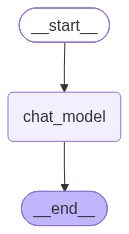

In [11]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great question! While whales often steal the spotlight, the ocean is home to a wonderfully diverse array of marine mammals—each with unique adaptations, behaviors, and conservation stories. Here’s a curated list of key groups and species worth exploring beyond whales:

🐋 **Cetaceans (Whales, Dolphins & Porpoises)**  
You know whales—but don’t miss:  
- **Dolphins**: Bottlenose (highly intelligent, social), orca (technically the largest dolphin—not a whale!), spinner dolphins (acrobatic), and river dolphins (e.g., Amazon pink river dolphin—freshwater-adapted and endangered).  
- **Porpoises**: Smaller, shyer cousi

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

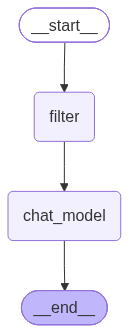

In [13]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great question! While whales (especially the large baleen and toothed whales) often steal the spotlight, the ocean is home to a wonderfully diverse array of marine mammals—many with fascinating adaptations, behaviors, and conservation stories. Here’s a curated list of other key groups and standout species worth exploring:

🐋 **Cetaceans (beyond the “big” whales):**  
- **Dolphins & Porpoises**: Highly intelligent, social, and ecologically vital. Compare bottlenose dolphins (coastal, acrobatic, well-studied) vs. harbor porpoises (shy, smaller, echolocation specialists). Don’t miss the critically endangered **vaqui

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

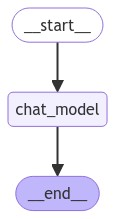

In [11]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [15]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [16]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Great question! While whales (especially the large baleen and toothed whales) often steal the spotlight, the ocean is home to a wonderfully diverse array of marine mammals—many with fascinating adaptations, behaviors, and conservation stories. Here’s a curated list of other key groups and standout species worth exploring:

🐋 **Cetaceans (beyond the “big” whales):**  
- **Dolphins & Porpoises**: Highly intelligent, social, 

In [17]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================

Great question! While whales (especially the large baleen and toothed whales) often steal the spotlight, the ocean is home to a wonderfully diverse array of marine mammals—many with fascinating adaptations, behaviors, and conservation stories. Here’s a curated list of other key groups and standout species worth exploring:

🐋 **Cetaceans (beyond the “big” whales):**  
- **Dolphins & Porpoises**: Highly intelligent, social, and ecologically vital. Compare bottlenose dolphins (coastal, acrobatic, well-studied) vs. harbor porpoises (shy, smaller, echolocation specialists). Don’t miss the critically endangered **vaquita**, the world’s rarest marine mammal (<10 individuals remain).  
- **Beaked whales**: Deep-diving, elusive, and poorly understood—the deepest and longest divers among mammals (e.g., Cuvier’s beaked whale: >2,900 m depth, >3+ hours submerged!). Often victims of naval sonar impacts.

🦭 **Pinnipeds

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

In [22]:
from langchain_core.messages import trim_messages, HumanMessage, AIMessage
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",  # 或其他 Qwen 模型名称
    trust_remote_code=True
)

# ✅ 定义符合 LangChain 要求的 token_counter 函数
def qwen_token_counter(messages):
    """将 LangChain Messages 转换为文本并计算 token 数"""
    text = "\n".join(msg.content for msg in messages if hasattr(msg, 'content'))
    return len(tokenizer.encode(text))

D:\pyprojject\langchain-academy\lc-academy-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\pyprojject\langchain-academy\lc-academy-env\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--Qwen--Qwen2.5-7B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. I

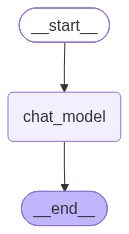

In [23]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=qwen_token_counter,
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [25]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=qwen_token_counter,
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

In [26]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r